In [1]:
%load_ext autoreload
%autoreload 2

from os import path
from glob import glob
import itertools

from tqdm.auto import tqdm
import numpy as np
import pandas as pd
from scipy.stats import linregress, ttest_rel, wilcoxon
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import mne

from notifmmn import erputils, datautils, statsutils, plotutils

from notifmmn.defs import *

%matplotlib widget

In [2]:
participants = pd.read_csv('participant_details.csv', index_col=0)
tones = participants[['SN_tone', 'Tone_delay']].sort_values('Tone_delay')['SN_tone'].unique() # tones sorted by delay
delays = participants['Tone_delay'].rename('tone delay')
# n100_latencies = pd.read_csv(path.join(resultdir, 'n100_latencies.csv'), index_col=[0, 1])

In [3]:
# normalize the participant information
participants = participants.rename(dict(b1_deviant='b1', b2_deviant='b2', b3_deviant='b3'), axis=1)
participants['b1'] = participants['b1'].map(dict(BT='BN/SN', SN='SN/BN', CN='CN/CN')).fillna('x/x')
participants['b2'] = participants['b2'].map(dict(BT='BN/SN', SN='SN/BN', CN='CN/CN')).fillna('x/x')
participants['b3'] = participants['b3'].map(dict(BT='BN/SN', SN='SN/BN', CN='CN/CN')).fillna('x/x')
participants.head()

,age,is_controlled_block,gender,profession,b1,b2,b3,comments,SN_tone,Tone_delay,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14
participant_id,,,,,,,,,,,,,,
sd011,30.0,N,M,PG_acd,SN/BN,BN/SN,x/x,FT10 noisy channel interpolated and further r...,Hello_inMoto,0.008617,NaN,NaN,NaN,NaN
sd012,25.0,N,M,PG_acd,SN/BN,BN/SN,x/x,No bad channel,Whoop_doop,0.036576,NaN,NaN,NaN,NaN
sd013,25.0,N,M,PG_acd,SN/BN,BN/SN,x/x,TP10 noisy channel interpolated and further r...,Hello_inMoto,0.008617,NaN,NaN,NaN,NaN
sd014,28.0,N,M,PG_acd,SN/BN,BN/SN,x/x,bad electrode = None Bad subject only very few...,droplet,0.034830,NaN,NaN,NaN,NaN
sd015,31.0,N,M,PG_acd,SN/BN,BN/SN,x/x,bad electrode = None,realme_fun,0.006780,NaN,NaN,NaN,NaN


In [4]:
# list all preprocessed files
# preprocessing involves manual curation, band pass filtering,
# down sampling, removal of eye artifacts, and epoching
files = sorted(glob(path.join(rawdir, 'preprocessed', '*')))
print(len(files), 'files available for analysis.')
# sorted(files)

56 files available for analysis.


# Bootstrapping to get uncertainty in ERP peaks

## Code development

In [ ]:
def _compute_peak_latency_amplitudes(erps, window, extrema=-1):
    '''
    Computes the peak latency and peak amplitude of a positive or negative peak
    (determined by extrema parameter) within a given window.
    '''
    pls = (extrema*erps.loc[window[0]:window[1]]).idxmax()
    pas = pd.Series([erps[c].loc[t] for c,t in zip(erps.columns, pls)], index=pls.index)
    # peaks at boundaries should not be considered peaks, so we require
    # that peaks are at least 5 ms away fron boundaries of the window
    pls[(pls<window[0]+0.005)|(pls>window[1]-0.005)] = np.nan
    pas[(pls<window[0]+0.005)|(pls>window[1]-0.005)] = np.nan
    return pd.concat(dict(
        PL=pls,
        PA=pas
    ), axis=1)

def _compute_areal_latency_amplitude(erps, window, latency_fractions=[0.25], extrema=-1):
    '''
    Computes the area under curve within the window to obtain the amplitude
    and the times at which the area crosses certain fractions to obtain latency.
    '''
    erps = (erps*extrema).loc[window[0]:window[1]]
    # detrend the ERPs so that end points are both at 0
    erps = erps.apply(lambda c: c - c.iloc[0] - (c.iloc[-1]-c.iloc[0])*np.arange(len(c))/len(c))
    amp = erps.sum()
    cs = erps.cumsum()
    tfs = {'TWMA':amp/len(erps)*extrema}
    for f in latency_fractions:
        tfs[f'FAL_{f}'] = (cs < amp*f).cumsum().idxmax()
    return pd.concat(tfs, axis=1)

def compute_single_erp_scores(erps, window, latency_fractions=[0.25], extrema=-1):
    '''
    Returns the following scores for an ERP waveform derived by averaging the epochs
    1. peak amplitude (of the highest peak in the window) [PA]
    2. peak latency (of the highest peak in the window) [PL]
    3. time-window mean amplitude [TWMA]
    4. fractional area latency [FAL]
    erps is a list of pandas dataframes
    '''
    return pd.concat([
        _compute_peak_latency_amplitudes(erps[0], window, extrema),
        _compute_areal_latency_amplitude(erps[0], window, latency_fractions, extrema)
    ], axis=1)

def compute_dwave_scores(erps, window, latency_fractions=[0.25], picks=None, extrema=-1):
    '''
    Returns the following scores for an ERP difference wave derived by averaging
    the two groups of epochs and subtracting group 1 from group 0
    1. peak amplitude (of the highest peak in the window) [PA]
    2. peak latency (of the highest peak in the window) [PL]
    3. time-window mean amplitude [TWMA]
    4. fractional area latency [FAL]
    '''
    dwave = erps[0] - erps[1]
    return pd.concat([
        _compute_peak_latency_amplitudes(dwave, window, extrema),
        _compute_areal_latency_amplitude(dwave, window, latency_fractions, extrema)
    ], axis=1)

def compute_bootstrapped_scores(epochs, fn, n_iterations, sample_size=None, picks=None, **kwargs):
    '''
    Compute score(s) with SEM by bootstrapping over epochs
    epochs: an instance of epochs, or list of epoch instances when more than one are required (for example for a difference wave)
    fn: the function to be called to evaluate the parameters for each resampling of epochs
    fn must accept a list of epochs as a pandas dataframe (indexed by epoch and time)
    fn must return a set of scores as a pandas series and the list of generated erps for each input epoch
    n_iterations: number of times resampling should be performed
    sample_size: int or list of ints (number of samples to draw in each iteration). default None will use the same number of samples as original epochs instance
    kwargs: arguments to be passed to the function fn
    '''
    if not isinstance(epochs, list):
        epochs = [epochs]
    if sample_size is None:
        sample_size = [len(x) for x in epochs]
    if picks is None:
        picks = epochs[0].columns
    
    # convert epochs to dataframes for faster computation inside the loop
    epochs = [
        e.to_data_frame().drop('condition', axis=1).set_index(['time', 'epoch'])[picks]\
            .unstack('time').T.groupby('time').mean().T for e in epochs
    ]
    erp_list = []
    for e, ss in zip(epochs, sample_size):
        erps = {}
        for itr in range(n_iterations):
            erps[itr] = e.sample(ss, replace=True).mean()
        erp_list.append(pd.concat(erps, axis=1))
    return fn(erp_list, **kwargs), erp_list

def get_erp_sem(epochs, n_iterations, sample_size=None, verifiplot=True, **kwargs):
    '''
    Returns the scores, erps, errors (encountered in each bootstrapped iteration) and figure object (if verifiplot)
    epochs: if single epochs instance, computes single erp scores
            if list of two epochs, computes the scores for the difference wave
    n_iterations: number of bootstrap iterations to run
    sample_size: number of epochs in each bootstrap iteration (defaults to the number of epochs in original epochs)
    verifiplot: setting True (default) will plot the ERPs (or difference waves) across bootstrapped iterations
    kwargs: arguments required for single wave or difference wave score computation
    kwargs include window (tuple), latency_fractions (list, for computing fractional area latencies), picks (to average over), extrema (whether to find minima or maxima)
    '''
    if not isinstance(epochs, list):
        epochs = [epochs]
    if len(epochs)==1:
        scores, erps = compute_bootstrapped_scores(
            epochs, compute_single_erp_scores, n_iterations=n_iterations, sample_size=sample_size, **kwargs
        )
        erps = erps[0]
    elif len(epochs)==2:
        scores, erps = compute_bootstrapped_scores(
            epochs, compute_dwave_scores, n_iterations=n_iterations, sample_size=sample_size, **kwargs
        )
        erps = erps[0] - erps[1]
    else:
        raise ValueError('exactly one or two sets of epochs must be given.')

    f = None
    if verifiplot:
        window = kwargs.pop('window')
        f, ax = plt.subplots(figsize=(8, 3), tight_layout=True)
        erps.plot(ax=ax, c='C0', alpha=0.01, legend=False)
        ax.scatter(scores.PL, scores.PA, s=1, c='k')
        ax.set_xlabel('time (s)')
        ax.set_ylabel('voltage ($\mu V$)')
        ax.axvspan(*window, color='gray', alpha=0.1)
        ax.annotate(
            scores.aggregate(['mean', 'std']).to_string(float_format='{:.3f}'.format, col_space=8, justify='right'),
            (10, 10), xycoords='axes pixels', family='monospace'
        )
    return scores, erps, f

In [5]:
fname = '../data/raw/preprocessed/sub-sd025-epo.fif'
sub = path.basename(fname).split('-')[1]
_epochs = mne.read_epochs(fname, verbose='ERROR').apply_baseline(verbose='ERROR')

In [6]:
# test the erp_scores function
__epochs = _epochs['S14'].to_data_frame().drop('condition', axis=1).set_index(['time', 'epoch']).mean(axis=1).unstack('time')
__erp = __epochs.mean().to_frame()
window = (0.18, 0.25)

scores = compute_single_erp_scores([__erp], window=window, latency_fractions=[0.01, 0.25, 0.5, 0.99])

f, ax = plt.subplots(figsize=(6, 3), tight_layout=True)
__erp.plot(ax=ax)
ax.axvline(window[0], c='gray')
ax.axvline(window[1], c='gray')
ax.scatter([scores['PL']], [scores['PA']])
ax.axvline(scores.loc[0]['FAL_0.01'], c='r', label='FAL 0.01')
ax.axvline(scores.loc[0]['FAL_0.25'], c='g', label='FAL 0.25')
ax.axvline(scores.loc[0]['FAL_0.5'], c='b', label='FAL 0.5')
ax.axvline(scores.loc[0]['FAL_0.99'], c='r', label='FAL 0.99')
ax.legend()

scores

NameError: name 'compute_single_erp_scores' is not defined

In [ ]:
# directly test the bootstrap function
scores, erps = compute_bootstrapped_scores(_epochs['S14'], compute_single_erp_scores, n_iterations=10, window=(0.18, 0.24), picks=['Fz', 'FCz', 'Cz'])

In [ ]:
# test bootstrapping function for single ERPs through SEM wrapper
n1_win = (0.18, 0.25)
scores_bn, erps, f_bn = get_erp_sem(_epochs['S14'], n_iterations=100, window=window, picks=['Fz', 'FCz', 'Cz'])
scores_sn, erps, f_sn = get_erp_sem(_epochs['S24'], n_iterations=100, window=window, picks=['Fz', 'FCz', 'Cz'])
f_bn.get_axes()[0].set_title('BN', y=0.9, loc='right')
f_sn.get_axes()[0].set_title('SN', y=0.9, loc='right');

In [ ]:
# test bootstrapping function for difference wave (MMN) ERPs
mmn_win = (0.18, 0.32)
scores_bn, erps, f_bn = get_erp_sem([_epochs['S25'], _epochs['S14']], n_iterations=500, window=mmn_win, picks=['Fz', 'FCz', 'Cz'])
scores_sn, erps, f_sn = get_erp_sem([_epochs['S15'], _epochs['S24']], n_iterations=500, window=mmn_win, picks=['Fz', 'FCz', 'Cz'])
f_bn.get_axes()[0].set_title('BN', y=0.9, loc='right')
f_sn.get_axes()[0].set_title('SN', y=0.9, loc='right');

## Usage example with library
In the example, only 50 iterations are used to run it faster. However at least 1000 iterations should be used for final analysis.

In [7]:
# load the data
fname = '../data/raw/preprocessed/sub-sd056-epo.fif'
sub = path.basename(fname).split('-')[1]
_epochs = mne.read_epochs(fname, verbose='ERROR').apply_baseline(verbose='ERROR')

BN scores:


,PL,PA,TWMA,FAL_0.25
mean,0.222043,-2.433654,-1.069783,0.205793
std,0.002394,0.366140,0.129148,0.001883


SN scores:


,PL,PA,TWMA,FAL_0.25
mean,0.217961,-1.839438,-1.797979,0.207113
std,0.001550,0.422314,0.149022,0.001224


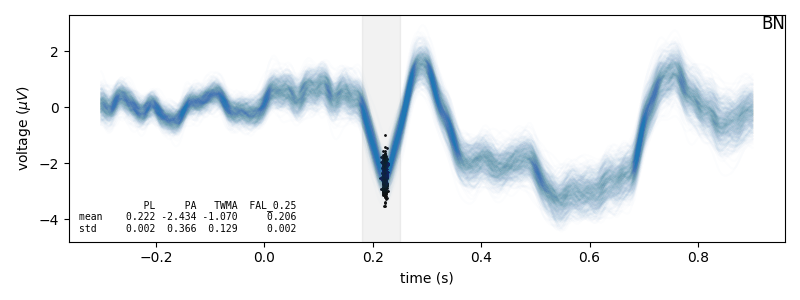

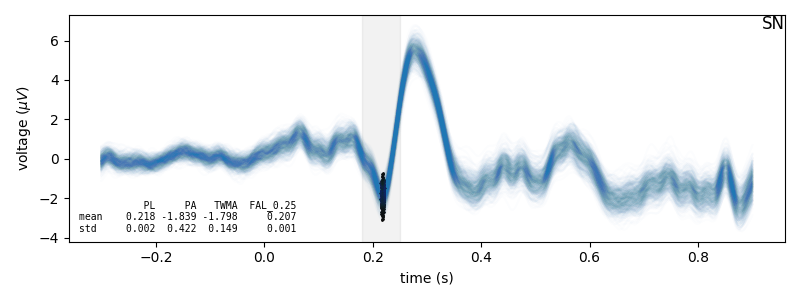

In [8]:
# get N1 scores
# in general N1 windows can be defined between tone_delay + 0.18 to tone_delay+0.24 (seconds)
# tone delays can be read from `participant_details.csv`
n1_win = (0.18, 0.25)
scores_bn, _, f_bn = erputils.get_erp_sem(_epochs['S14'], n_iterations=500, window=n1_win, picks=['Fz', 'FCz', 'Cz'])
scores_sn, _, f_sn = erputils.get_erp_sem(_epochs['S24'], n_iterations=500, window=n1_win, picks=['Fz', 'FCz', 'Cz'])
f_bn.get_axes()[0].set_title('BN', y=0.9, loc='right')
f_sn.get_axes()[0].set_title('SN', y=0.9, loc='right')
print('BN scores:')
display(scores_bn.aggregate(['mean', 'std']))
print('SN scores:')
display(scores_sn.aggregate(['mean', 'std']))

BN scores:


,PL,PA,TWMA,FAL_0.25
mean,0.250172,-3.406406,-0.11197,0.263254
std,0.041295,0.978112,0.40355,0.051733


SN scores:


,PL,PA,TWMA,FAL_0.25
mean,0.236301,-7.899959,-2.236243,0.218930
std,0.002383,0.929996,0.427426,0.003569


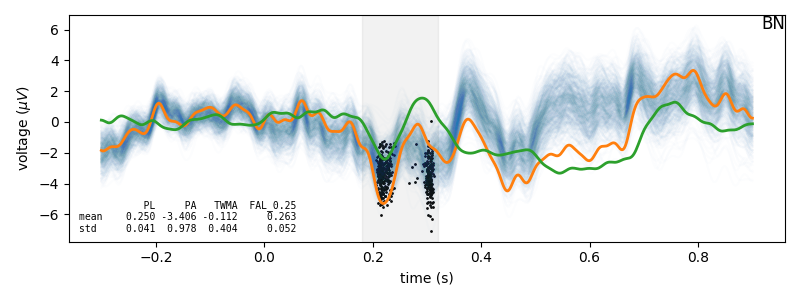

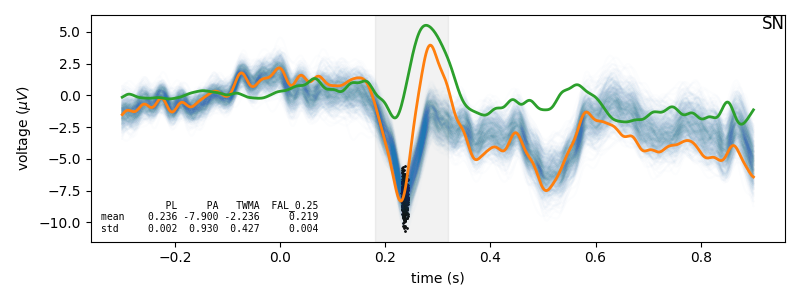

In [10]:
# get MMN scores
# note that latencies have to be adjusted to account for N1 latencies
# the function returns latencies wrt epoch (ie stimulus onset)
mmn_win = (0.18, 0.32)
scores_bn, _, f_bn = erputils.get_erp_sem([_epochs['S25'], _epochs['S14']], n_iterations=500, window=mmn_win, picks=['Fz', 'FCz', 'Cz'])
scores_sn, _, f_sn = erputils.get_erp_sem([_epochs['S15'], _epochs['S24']], n_iterations=500, window=mmn_win, picks=['Fz', 'FCz', 'Cz'])
f_bn.get_axes()[0].set_title('BN', y=0.9, loc='right')
f_sn.get_axes()[0].set_title('SN', y=0.9, loc='right')
print('BN scores:')
display(scores_bn.aggregate(['mean', 'std']))
print('SN scores:')
display(scores_sn.aggregate(['mean', 'std']))

# Compute ERP scores for all subjects

## Compute N1 scores

In [ ]:
stim_type = 'STD' # can be STD or DEV
sortby = 'block' # can be 'stim' or 'block'; determines the column order in ERP plot
niter = 500
latency_fracs = [0.5]
electrodes = 'fronto_central_midline' # can be 'fronto_central_midline', 'supratemporal', 'right_frontal'
n1_win = np.array([0.16, 0.28]) # n1 will be searched in this window, adjusted for the tone onset time

# vibration N1 seems to come quite late but strong, so adjust their window location
delays.loc[delays[delays>0.1].index] = 0.23

for electrodes in locations.keys():
    # this dictionary will store the N1 scores and erps for each subject and stimulus type
    n1_scores = dict(SN={}, BN={}, CN={})
    n1_erps = dict(SN={}, BN={}, CN={})
    
    # set up the figure
    f_n1, axes_n1 = plt.subplots(
        len(files), 3, figsize=(12, 2*len(files)),
        tight_layout=True, sharex=True, sharey=True
    )
    for i, fname in enumerate(tqdm(sorted(files), desc=electrodes)):
        sub = path.basename(fname).split('-')[1]
        _epochs = mne.read_epochs(fname, verbose='ERROR').apply_baseline(verbose='ERROR')
    
        epoch_names = {x: triggers.get(f'{x} {stim_type}', None) for x in ['BN', 'SN', 'CN']}
        blocks = {x:participants.loc[sub][x].split('/')[1 if stim_type=='STD' else 0] for x in ['b1', 'b2', 'b3']}
    
        for j, (block, stim) in enumerate(blocks.items()):
            if stim=='x':
                continue
            if sortby=='block':
                ax = axes_n1[i][j]
            else:
                ax = axes_n1[i][stims.index(stim)]
            if stim=='SN':
                win = n1_win + delays[sub]
            else:
                win = n1_win
            try:
                n1_scores[stim][sub], n1_erps[stim][sub], _ = erputils.get_erp_sem(
                    _epochs[triggers[f'{stim} {stim_type}']], n_iterations=niter, window=win,
                    picks=locations[electrodes], latency_fractions=latency_fracs, ax=ax
                )
            except:
                pass
            ax.set_title(f'{sub} {stim} {stim_type} ({block}) N1', y=0.85, loc='right')
    f_n1.savefig(path.join(tmpdir, f'sem_n1_{stim_type}_sorted_{sortby}_{electrodes}.png'))
    plt.close(f_n1)
    
    n1_scores = pd.concat(
        {t: pd.concat(v) for t, v in n1_scores.items()},
        names=['stim', 'subject', 'iteration']
    )
    n1_scores.to_csv(f'scores_n1_{stim_type}_{electrodes}.csv')
    
    n1_erps = pd.concat(
        {t: pd.concat(v) for t, v in n1_erps.items()},
        names=['stim', 'subject', 'time']
    ).mean(axis=1).unstack(['stim', 'subject']).sort_index(axis=1)
    n1_erps.to_csv(path.join(tmpdir, f'erps_n1_{stim_type}_{electrodes}.csv'))

fronto_central_midline:   0%|          | 0/55 [00:00<?, ?it/s]

supratemporal:   0%|          | 0/55 [00:00<?, ?it/s]

right_frontal:   0%|          | 0/55 [00:00<?, ?it/s]

inverse_mastoid:   0%|          | 0/55 [00:00<?, ?it/s]

## Compute MMN scores

In [ ]:
stim_type = 'STD'
mmn_type = 'across' # can be 'across' or 'within' block
niter = 500
latency_fracs = [0.5]
electrodes = 'fronto_central_midline' # can be 'fronto_central_midline', 'supratemporal', 'right_frontal'

# n1 will be searched in this window, adjusted for the tone onset time
# reference: https://pmc.ncbi.nlm.nih.gov/articles/PMC6828569/
mmn_win = np.array([0.02, 0.12])

for electrodes in locations.keys():
    
    # read N1 scores instead of recomputing (N1 is always using fronto-central electrodes!)
    n1_scores = datautils.read_n1_scores(dir='./', stim_type=stim_type, electrodes='fronto_central_midline')
    # aggregate metrics for N1 scores
    n1_agg = datautils.aggregate_n1_scores(n1_scores)
    
    # this dictionary will store the N1 scores and erps for each subject and stimulus type
    mmn_scores = dict(SN={}, BN={})
    mmn_erps = dict(SN={}, BN={})
    if mmn_type=='within':
        mmn_scores.update(dict(CN={}))
        mmn_erps.update(dict(CN={}))
    
    # set up the figure
    f_mmn, axes_mmn = plt.subplots(
        len(files), 3, figsize=(12, 2*len(files)),
        tight_layout=True, sharex=True, sharey=True
    )
    for i, fname in enumerate(tqdm(sorted(files), desc=electrodes)):
        sub = path.basename(fname).split('-')[1]
        _epochs = mne.read_epochs(fname, verbose='ERROR').apply_baseline(verbose='ERROR')
    
        for j, stim in enumerate(stims):
            ax = axes_mmn[i][j]
            win = mmn_win
            if mmn_type=='across':
                if stim == 'CN':
                    continue # CN cannot have across MMN, so skip computation
                try:
                    epochs_to_use = [_epochs[triggers[f'{stim} DEV']], _epochs[triggers[f'{stim} STD']]]
                    offsets = -int(n1_agg.loc[(stim, sub), 'PL_mean']*sfreq)
                except:
                    print(f'Failed to generate epochs for sub {sub} {stim}...')
                    continue
            else:
                try:
                    epochs_to_use = [_epochs[triggers[f'{stim} DEV']], _epochs[triggers[f'{stim} DEV'].replace('5', '4')]]
                except:
                    print(f'Failed to generate epochs for sub {sub} {stim}...')
                    continue
                offsets = [
                    -int(n1_agg.loc[(stim, sub), 'PL_mean']*sfreq),
                    -int(n1_agg.loc[(triggers_r[triggers[f'{stim} DEV'].replace('5', '4')][:2], sub), 'PL_mean']*sfreq)
                ]
            # try:
            mmn_scores[stim][sub], mmn_erps[stim][sub], _ = erputils.get_erp_sem(
                epochs_to_use, n_iterations=niter, window=mmn_win,
                picks=locations[electrodes], latency_fractions=latency_fracs, offsets=offsets, ax=ax
            )
            # except:
            #     print('Failed to compute MMN...')
            #     pass
            ax.set_title(f'{sub} {stim} {mmn_type} MMN', y=0.85, loc='right')
    f_mmn.savefig(path.join(tmpdir, f'sem_mmn_{mmn_type}_{electrodes}.png'))
    plt.close(f_mmn)
    
    mmn_scores = pd.concat(
        {t: pd.concat(v) for t, v in mmn_scores.items()},
        names=['stim', 'subject', 'iteration']
    )
    mmn_scores.to_csv(f'scores_mmn_{mmn_type}_{electrodes}.csv')
    
    mmn_erps = pd.concat(
        {t: pd.concat(v) for t, v in mmn_erps.items()},
        names=['stim', 'subject', 'time']
    ).mean(axis=1).unstack(['stim', 'subject']).sort_index(axis=1)
    mmn_erps.to_csv(path.join(tmpdir, f'erps_mmn_{mmn_type}_{electrodes}.csv'))

inverse_mastoid:   0%|          | 0/55 [00:00<?, ?it/s]

right_frontal:   0%|          | 0/55 [00:00<?, ?it/s]

supratemporal:   0%|          | 0/55 [00:00<?, ?it/s]

fronto_central_midline:   0%|          | 0/55 [00:00<?, ?it/s]

# Individual level analysis

## Adaptation
Do we see adaptation in N1 for STD stimuli? For deviant?

We see mild long term adaptation, towards the last 1/3rd of the block.  

Devaints seem to have a larger ERP than standards, including the standard immediately after deviants (to be confirmed after Prakash uploads the full epochs including bad ones to correctly identify standards after deviants).  

Possible solutions:

1. There are times in the block when the STD ERPs are of a magnitude comparable to the DEV ERPs. So we might be able to use them for amplitude-matched MMN computation. This seems to be an established practice, see cell below.
2. Rescaling to standardize N1s and then computing ERPs. This is apparantly not done, so we will have to justify it if we do this. But worth trying!
3. Statistical modeling approaches to account for adaptation.

Amplitude-matched standards have been used for MMN computation in published literature to control for adaptation effects. This approach helps ensure that the difference between deviant and standard ERPs is not confounded by adaptation.

**References:**

- **Wiens, S., Szychowska, M., & Nilsson, M. E. (2016).** "Visual mismatch negativity (vMMN): A review of findings and methodologies." *Psychophysiology*, 53(3), 215–232.  
  > Discusses amplitude-matching of standards to deviants to control for adaptation.

- **Jacobsen, T., & Schröger, E. (2001).** "Is there pre-attentive memory-based comparison of pitch?" *Psychophysiology*, 38(4), 723–727.  
  > Used amplitude-matched standards for MMN analysis.

- **May, P. J., & Tiitinen, H. (2010).** "Mismatch negativity (MMN), the deviance-elicited auditory deflection, explained." *Psychophysiology*, 47(1), 66–122.  
  > Reviews methodological approaches, including amplitude-matching standards.

- **Näätänen, R., Paavilainen, P., Rinne, T., & Alho, K. (2007).** "The mismatch negativity (MMN) in basic research of central auditory processing: A review." *Clinical Neurophysiology*, 118(12), 2544–2590.  
  > Discusses adaptation and the use of amplitude-matched standards.

These papers describe and justify the use of amplitude-matched standards to avoid adaptation confounds in MMN studies.

Certainly. Statistical modeling approaches have been used to account for adaptation effects in MMN studies, though they are less common than amplitude-matching. These methods typically involve including adaptation as a covariate, using mixed-effects models, or regression-based approaches.

**References:**

- **Garrido, M. I., Kilner, J. M., Stephan, K. E., & Friston, K. J. (2009).** "The mismatch negativity: A review of underlying mechanisms." *Clinical Neurophysiology*, 120(3), 453–463.  
  > Discusses the use of statistical models to separate adaptation and deviance detection mechanisms.

- **Winkler, I., Karmos, G., & Näätänen, R. (1996).** "Adaptive modeling of the auditory event-related potential: A new approach to the MMN." *Biological Psychology*, 43(2), 147–162.  
  > Introduces adaptive modeling to account for stimulus history and adaptation.

- **Sussman, E. S., Chen, S., Sussman-Fort, J., & Dinces, E. (2014).** "The five myths of MMN: Redefining how to use MMN in basic and clinical research." *Brain Topography*, 27(4), 553–564.  
  > Reviews methodological issues and discusses statistical approaches to control for adaptation.

- **Lieder, F., Stephan, K. E., Daunizeau, J., Garrido, M. I., & Friston, K. J. (2013).** "A neurocomputational model of the mismatch negativity." *PLoS Computational Biology*, 9(11), e1003288.  
  > Uses computational and statistical modeling to separate adaptation from deviance detection.

These papers describe statistical and computational modeling approaches to account for adaptation in MMN analysis.

In [39]:
# load epochs for a subject
fname = '../data/raw/preprocessed/preprocessed_mark_bad_epoch/sub-sd034-epo.fif'
sub = path.basename(fname).split('-')[1]
_epochs = mne.read_epochs(fname, verbose='ERROR').apply_baseline(verbose='ERROR')
_epochs = datautils.epochs_to_df_with_annotations(_epochs)

### Long term adaptation
Adaptation over the duration of the block

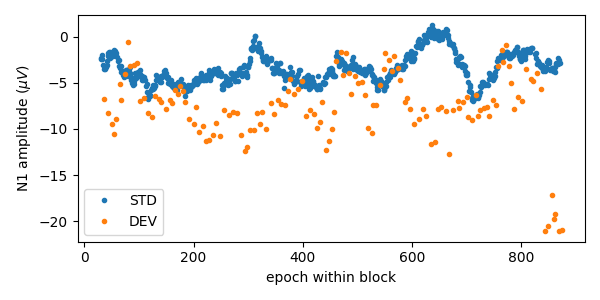

In [86]:
# generate rolling window erps and compute scores
n1_win = np.array([0.16, 0.28]) # n1 will be searched in this window, adjusted for the tone onset time
# vibration N1 seems to come quite late but strong, so adjust their window location
delays.loc[delays[delays>0.1].index] = 0.23

n1_win = n1_win + delays[sub]

lta_scores_std = erputils.compute_single_erp_scores(
    [_epochs.xs(14, level='condition').xs(True, level='valid').rolling(window=50, center=True).mean().dropna().T],
    window=n1_win, latency_fractions=[0.25], extrema=-1
).reset_index(['cblock', 'cindex'], drop=True)
lta_scores_std.index = lta_scores_std.index%900
lta_scores_dev = erputils.compute_single_erp_scores(
    [_epochs.xs(25, level='condition').xs(True, level='valid').rolling(window=10, center=True).mean().dropna().T],
    window=n1_win, latency_fractions=[0.25], extrema=-1
).reset_index(['cblock', 'cindex'], drop=True)
lta_scores_dev.index = lta_scores_dev.index%900

f, ax = plt.subplots(figsize=(6, 3), tight_layout=True)

lta_scores_std['PA'].plot(ax=ax, marker='.', lw=0, label='STD')
lta_scores_dev['PA'].plot(ax=ax, c='C1', marker='.', lw=0, label='DEV')
ax.set_xlabel('epoch within block')
ax.set_ylabel('N1 amplitude ($\mu V$)')
ax.legend();

### Short term adaptation
Adaptation immediately following stimulus change

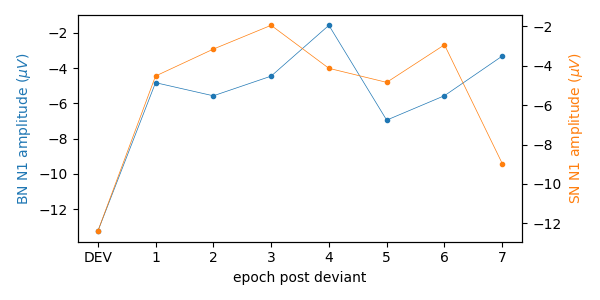

In [52]:
n1_win = np.array([0.16, 0.28]) # n1 will be searched in this window, adjusted for the tone onset time
sta_scores = pd.concat({
    c : erputils.compute_single_erp_scores(
        [_epochs.xs(True, level='valid').xs(c, level='condition').groupby(['cindex']).mean().T],
        window=n1_win if c in [14, 25, 35] else n1_win+delays[sub], latency_fractions=[0.25], extrema=-1
    ) for c in [14, 15, 24, 25]
})
sta_scores.loc[(14, 0)] = sta_scores.loc[(25, 0)]
sta_scores.loc[(24, 0)] = sta_scores.loc[(15, 0)]

f, ax = plt.subplots(figsize=(6, 3), tight_layout=True)
ax2 = ax.twinx()

sta_scores.loc[14]['PA'][:8].plot(ax=ax, marker='.', lw=0.5)
sta_scores.loc[24]['PA'][:8].plot(ax=ax2, marker='.', lw=0.5, c='C1')
ax.set_xlabel('epoch post deviant')
ax.set_ylabel('BN N1 amplitude ($\mu V$)', c='C0')
ax2.set_ylabel('SN N1 amplitude ($\mu V$)', c='C1')
ax.set_xticks(range(8))
ax.set_xticklabels(['DEV', 1, 2, 3, 4, 5, 6, 7]);

### Amplitude-matched MMNs

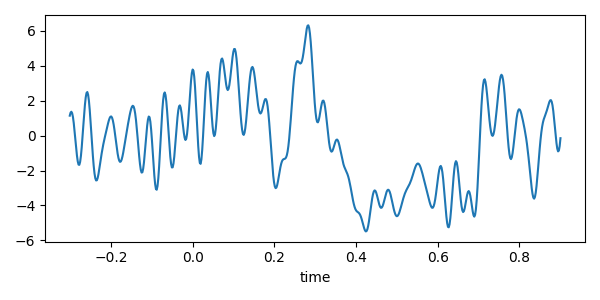

In [92]:
f, ax = plt.subplots(figsize=(6, 3), tight_layout=True)
_epochs.xs(14, level='condition').xs(True, level='valid').sample(25, replace=False).mean().T.plot(ax=ax);

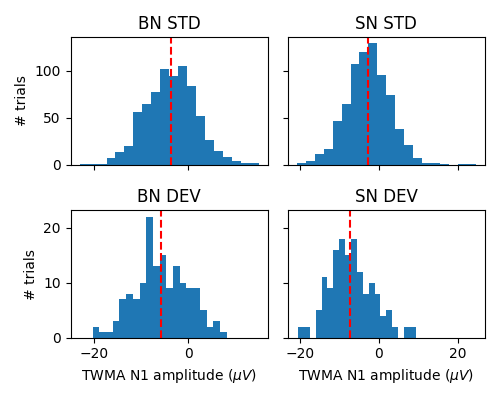

In [67]:
# compute trial-wise scores to estimate single-trial N1 amplitudes
scores = pd.concat({
    c: erputils.compute_single_erp_scores(
        [_epochs.xs(c, level='condition').xs(True, level='valid').T],
        window=n1_win if c in [14, 25, 35] else n1_win + delays[sub],
        latency_fractions=[0.25], extrema=-1
    )
    for c in [14, 24, 25, 15]
}, names=['condition', 'epoch', 'cblock', 'cindex'])
f, axes = plt.subplots(2, 2, figsize=(5, 4), tight_layout=True, sharex='col', sharey='row')
for ax, cond in zip(axes.flatten(), [14, 24, 25, 15]):
    _ = scores.xs(cond, level='condition')['TWMA'].plot(
        ax=ax, kind='hist', title=f'{triggers_r["S" + str(cond)]}', bins=20
    )
    ax.set_xlabel('TWMA N1 amplitude ($\mu V$)')
    ax.set_ylabel('# trials')
    ax.axvline(scores.xs(cond, level='condition')['TWMA'].median(), c='r', ls='--')

### Scaled-N1 MMNs

In [130]:
n1_agg = pd.concat({
    st : datautils.aggregate_n1_scores(datautils.read_n1_scores(dir='./', stim_type=st, electrodes='fronto_central_midline')) for st in ['STD', 'DEV']
})
n1_erps = pd.concat({
    st : datautils.read_n1_erps(dir=tmpdir, stim_type=st, electrodes='fronto_central_midline').T for st in ['STD', 'DEV']
})

# normalize all ERPs by STD N1 amplitudes
n1_erps_normalized = -n1_erps.T / n1_agg['PA_mean']
# align all N1 peaks to time 0
n1_erps_normalized = n1_erps_normalized.apply(lambda c: c.shift(-int(sfreq*n1_agg.loc[('STD', *c.name[1:])]['PL_mean'])))

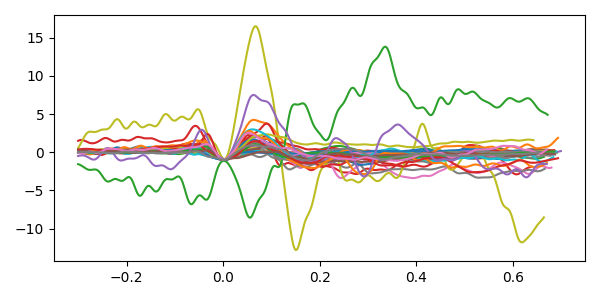

In [145]:
f, ax = plt.subplots(figsize=(6, 3), tight_layout=True)
ax.plot((n1_erps_normalized.T[(n1_agg['TWMA_mean']<-1)&(n1_agg['PL_std']<0.008)]).T['STD']['SN'], label='SN STD');

/tmp/ipykernel_2601985/961986073.py:1: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  scaled_mmns = n1_erps_normalized.stack(['stim', 'subject']).diff(axis=1)['DEV'].rename('MMN').unstack(['stim', 'subject']).drop('CN', axis=1)


(-2.0, 2.0)

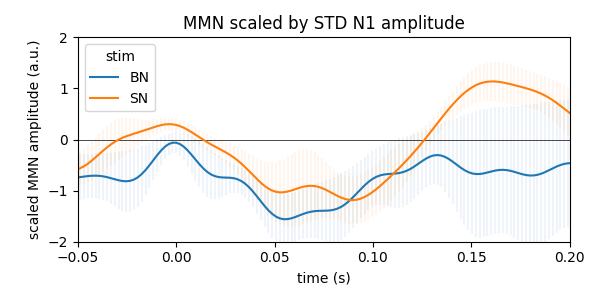

In [169]:
scaled_mmns = n1_erps_normalized.stack(['stim', 'subject']).diff(axis=1)['DEV'].rename('MMN').unstack(['stim', 'subject']).drop('CN', axis=1)
scaled_mmn_mean = scaled_mmns.T.groupby('stim').mean().T
scaled_mmn_sem = scaled_mmns.T.groupby('stim').sem().T
f, ax = plt.subplots(figsize=(6, 3), tight_layout=True)
scaled_mmn_mean.plot(ax=ax, yerr=scaled_mmn_sem, capsize=0)
ax.axhline(0, c='k', lw=0.5)
ax.set_ylabel('scaled MMN amplitude (a.u.)')
ax.set_xlabel('time (s)')
ax.set_title('MMN scaled by STD N1 amplitude')
for chd in ax.get_children():
    if type(chd)==mpl.collections.LineCollection:
        chd.set_alpha(0.075)
ax.set_xlim(-0.05, 0.2)
ax.set_ylim(-2, 2)

/tmp/ipykernel_2601985/2960912390.py:3: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  n1_erps_normalized.xs('sd025', level='subject', axis=1).stack('stim').diff(axis=1)['DEV'].unstack('stim').plot(ax=ax)


<Axes: xlabel='time'>

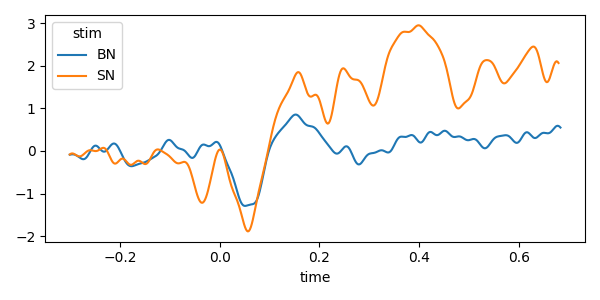

In [170]:
f, ax = plt.subplots(figsize=(6, 3), tight_layout=True)
# n1_erps_normalized.xs('sd025', level='subject', axis=1).plot(ax=ax)
n1_erps_normalized.xs('sd025', level='subject', axis=1).stack('stim').diff(axis=1)['DEV'].unstack('stim').plot(ax=ax)

### Use post-deviant standards as standards

## Subject inclusion

In [11]:
# load individual level data according to the settings below
electrodes = 'fronto_central_midline' # can be 'fronto_central_midline', 'supratemporal', 'right_frontal'
mmn_type = 'across' # can be 'across' or 'within' block

n1_scores = {
    stim_type: datautils.read_n1_scores(dir='./', stim_type=stim_type, electrodes=electrodes)
    for stim_type in ['STD', 'DEV']
}
n1_agg = {
    stim_type: datautils.aggregate_n1_scores(n1_scores[stim_type])
    for stim_type in ['STD', 'DEV']
}

mmn_scores = datautils.read_mmn_scores(dir='./', mmn_type=mmn_type, electrodes=electrodes)
mmn_agg = datautils.aggregate_mmn_scores(mmn_scores)

## N1 criteria

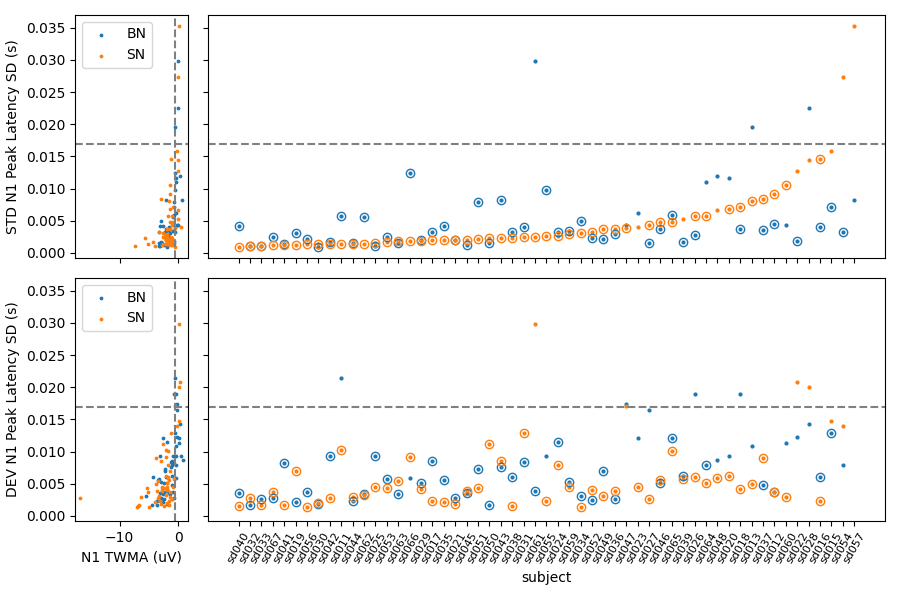

In [12]:
n1_pl_sem_thresh = 0.017
n1_twma_mean_thresh = -0.5

# these subjects pass the above defined criteria for N1 based inclusion
n1_passed_subjects = pd.concat({
    stim_type: n1_agg[stim_type][
        (n1_agg[stim_type]['PL_std']<n1_pl_sem_thresh)&
        (n1_agg[stim_type]['TWMA_mean']<n1_twma_mean_thresh)
    ].index.to_frame().groupby(level='stim').apply(lambda df: list(df['subject'])) for stim_type in ['STD', 'DEV']
})

# visualization of N1 based inclusion
f, [axes, axesD] = plt.subplots(2, 2, figsize=(9, 6), tight_layout=True, width_ratios=[1, 6], sharey=True, sharex='col')
axes[0].scatter(
    n1_agg['STD'].loc['BN', 'TWMA_mean'],
    n1_agg['STD'].loc['BN', 'PL_std'],
    c='C0', label='BN', s=3
)
axes[0].scatter(
    n1_agg['STD'].loc['SN', 'TWMA_mean'],
    n1_agg['STD'].loc['SN', 'PL_std'],
    c='C1', label='SN', s=3
)
axes[0].set_ylabel('STD N1 Peak Latency SD (s)')
axes[0].set_xlabel('N1 TWMA (uV)')
axes[0].axvline(n1_twma_mean_thresh, c='gray', ls='--')
axes[0].axhline(n1_pl_sem_thresh, c='gray', ls='--')
axes[0].legend(loc=2)

n1_agg['STD'].loc['BN', 'PL_std'].loc[
    n1_agg['STD'].loc['SN', 'PL_std'].sort_values().index
].plot(marker='o', lw=0, ax=axes[1], color='C0', ms=2)
n1_agg['STD'].loc['SN', 'PL_std'].sort_values().plot(marker='o', lw=0, ax=axes[1], color='C1', ms=2)
_s = pd.Series(np.nan, index=n1_agg['STD'].loc['SN', 'PL_std'].sort_values().index)
_s.loc[n1_passed_subjects['STD']['BN']] = n1_agg['STD'].loc['BN', 'PL_std'].sort_values().loc[n1_passed_subjects['STD']['BN']]
_s.plot(marker='o', lw=0, ax=axes[1], color='C0', ms=6, mfc='none')
_s = pd.Series(np.nan, index=n1_agg['STD'].loc['SN', 'PL_std'].sort_values().index)
_s.loc[n1_passed_subjects['STD']['SN']] = n1_agg['STD'].loc['SN', 'PL_std'].sort_values().loc[n1_passed_subjects['STD']['SN']]
_s.plot(marker='o', lw=0, ax=axes[1], color='C1', ms=6, mfc='none')
axes[1].axhline(n1_pl_sem_thresh, c='gray', ls='--')

axesD[0].scatter(
    n1_agg['DEV'].loc['BN', 'TWMA_mean'],
    n1_agg['DEV'].loc['BN', 'PL_std'],
    c='C0', label='BN', s=3
)
axesD[0].scatter(
    n1_agg['DEV'].loc['SN', 'TWMA_mean'],
    n1_agg['DEV'].loc['SN', 'PL_std'],
    c='C1', label='SN', s=3
)
axesD[0].set_ylabel('DEV N1 Peak Latency SD (s)')
axesD[0].set_xlabel('N1 TWMA (uV)')
axesD[0].axvline(n1_twma_mean_thresh, c='gray', ls='--')
axesD[0].axhline(n1_pl_sem_thresh, c='gray', ls='--')
axesD[0].legend(loc=2)

n1_agg['DEV'].loc['BN', 'PL_std'].loc[
    [x for x in n1_agg['STD'].loc['SN', 'PL_std'].sort_values().index if x in n1_agg['DEV'].loc['SN', 'PL_std'].index]
].plot(marker='o', lw=0, ax=axesD[1], color='C0', ms=2)
n1_agg['DEV'].loc['SN', 'PL_std'].loc[
    [x for x in n1_agg['STD'].loc['SN', 'PL_std'].sort_values().index if x in n1_agg['DEV'].loc['SN', 'PL_std'].index]
].plot(marker='o', lw=0, ax=axesD[1], color='C1', ms=2)
_s = pd.Series(np.nan, index=n1_agg['STD'].loc['SN', 'PL_std'].sort_values().index)
_s.loc[n1_passed_subjects['DEV']['BN']] = n1_agg['DEV'].loc['BN', 'PL_std'].loc[n1_passed_subjects['DEV']['BN']]
_s.plot(marker='o', lw=0, ax=axesD[1], color='C0', ms=6, mfc='none')
_s = pd.Series(np.nan, index=n1_agg['STD'].loc['SN', 'PL_std'].sort_values().index)
_s.loc[n1_passed_subjects['DEV']['SN']] = n1_agg['DEV'].loc['SN', 'PL_std'].loc[n1_passed_subjects['DEV']['SN']]
_s.plot(marker='o', lw=0, ax=axesD[1], color='C1', ms=6, mfc='none')
axesD[1].axhline(n1_pl_sem_thresh, c='gray', ls='--')

axesD[1].set_xticks(range(len(n1_agg['STD'].loc['BN', 'PL_std'])))
axesD[1].set_xticklabels(n1_agg['STD'].loc['SN', 'PL_std'].sort_values().index, rotation=60, fontsize=8);

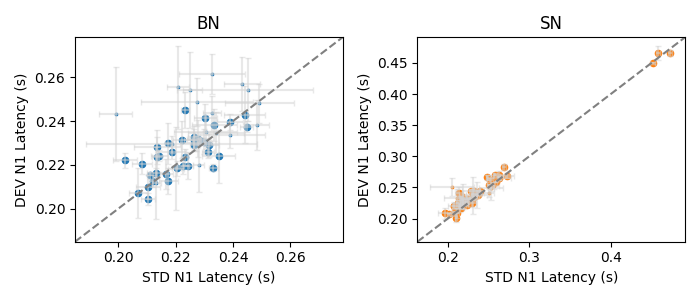

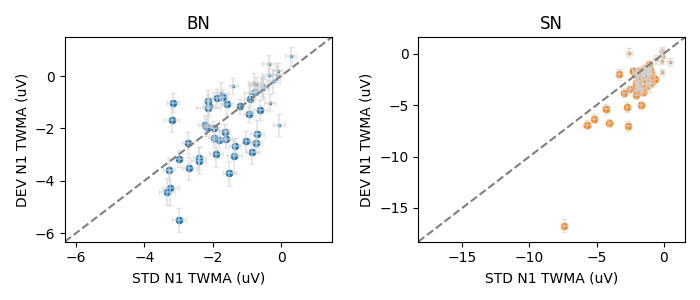

In [13]:
# create a set of all subjects that pass N1 based inclusion criteria for both STD and DEV
# and for both BN and SN stimuli
n1_inc = n1_passed_subjects.groupby('stim').apply(lambda df: list(set(df['STD'][df.name]).intersection(set(df['DEV'][df.name]))))
# n1_inc = set(n1_inc['BN']).intersection(set(n1_inc['SN']))

# scatter plot of N1 latencies for DEV vs STD for both BN and SN
f, axes = plt.subplots(1, 2, figsize=(7, 3), tight_layout=True)
for ax, stim in zip(axes, ['BN', 'SN']):
    ax.scatter(
        n1_agg['STD'].drop('sd057', level='subject').loc[stim, 'PL_mean'],
        n1_agg['DEV'].loc[stim, 'PL_mean'],
        c='C0' if stim=='BN' else 'C1', s=3
    )
    ax.errorbar(
        n1_agg['STD'].drop('sd057', level='subject').loc[stim, 'PL_mean'],
        n1_agg['DEV'].loc[stim, 'PL_mean'],
        xerr=n1_agg['STD'].drop('sd057', level='subject').loc[stim, 'PL_std'],
        yerr=n1_agg['DEV'].loc[stim, 'PL_std'],
        fmt='none', ecolor='lightgray', alpha=0.5, capsize=2
    )
    ax.set_title(stim)
    ax.set_xlabel('STD N1 Latency (s)')
    ax.set_ylabel('DEV N1 Latency (s)')
    lims = [
        min(ax.get_xlim()[0], ax.get_ylim()[0]),
        max(ax.get_xlim()[1], ax.get_ylim()[1])
    ]
    ax.plot(lims, lims, c='gray', ls='--')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    for s in n1_inc[stim]:
        ax.scatter(
            n1_agg['STD'].loc[(stim, s), 'PL_mean'],
            n1_agg['DEV'].loc[(stim, s), 'PL_mean'],
            c='C0' if stim=='BN' else 'C1', s=20, facecolors='none'
        )

# same plot but for amplitudes
f, axes = plt.subplots(1, 2, figsize=(7, 3), tight_layout=True)
for ax, stim in zip(axes, ['BN', 'SN']):
    ax.scatter(
        n1_agg['STD'].drop('sd057', level='subject').loc[stim, 'TWMA_mean'],
        n1_agg['DEV'].loc[stim, 'TWMA_mean'],
        c='C0' if stim=='BN' else 'C1', s=3
    )
    ax.errorbar(
        n1_agg['STD'].drop('sd057', level='subject').loc[stim, 'TWMA_mean'],
        n1_agg['DEV'].loc[stim, 'TWMA_mean'],
        xerr=n1_agg['STD'].drop('sd057', level='subject').loc[stim, 'TWMA_std'],
        yerr=n1_agg['DEV'].loc[stim, 'TWMA_std'],
        fmt='none', ecolor='lightgray', alpha=0.5, capsize=2
    )
    ax.set_title(stim)
    ax.set_xlabel('STD N1 TWMA (uV)')
    ax.set_ylabel('DEV N1 TWMA (uV)')
    lims = [
        min(ax.get_xlim()[0], ax.get_ylim()[0]),
        max(ax.get_xlim()[1], ax.get_ylim()[1])
    ]
    ax.plot(lims, lims, c='gray', ls='--')
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    for s in n1_inc[stim]:
        ax.scatter(
            n1_agg['STD'].loc[(stim, s), 'TWMA_mean'],
            n1_agg['DEV'].loc[(stim, s), 'TWMA_mean'],
            c='C0' if stim=='BN' else 'C1', s=20, facecolors='none'
        )

## MMN Criteria

In [ ]:
f, axes = plt.subplots(2, 3, figsize=(9, 5), tight_layout=True)
for i, stim in enumerate(stims):
    mmn_agg.loc[stim]['PL_std'].hist(ax=axes[0][i], bins=20, grid=False, cumulative=False)
    axes[0][i].set_title(stim)
    axes[0][i].set_xlabel('MMN Peak Latency SD (s)')
    axes[0][i].set_ylabel('Count')
    axes[0][i].axvline(0.028, c='gray', ls='--')
    mmn_agg.loc[stim]['TWMA_mean'].hist(ax=axes[1][i], bins=20, grid=False, cumulative=False)
    axes[1][i].set_xlabel('MMN TWMA (uV)')
    axes[1][i].set_ylabel('Count')
    axes[1][i].axvline(-0.5, c='gray', ls='--')

In [ ]:
mmn_pl_sem_thresh = 0.028
mmn_twma_mean_thresh = -0.2

# these subjects pass the above defined criteria for N1 based inclusion
mmn_passed_subjects = mmn_agg[(mmn_agg['PL_std']<mmn_pl_sem_thresh)&(mmn_agg['TWMA_mean']<mmn_twma_mean_thresh)].index
mmn_passed_subjects = mmn_passed_subjects.to_frame().groupby(level='stim').apply(lambda df: list(df['subject']))

# visualization of N1 based inclusion
f, axes = plt.subplots(1, 2, figsize=(9, 3), tight_layout=True, width_ratios=[1, 6], sharey=True)
axes[0].scatter(mmn_agg.loc['BN', 'TWMA_mean'], mmn_agg.loc['BN', 'PL_std'], c='C0', label='BN', s=3)
axes[0].scatter(mmn_agg.loc['SN', 'TWMA_mean'], mmn_agg.loc['SN', 'PL_std'], c='C1', label='SN', s=3)
axes[0].set_ylabel('MMN Peak Latency SD (s)')
axes[0].set_xlabel('MMN TWMA (uV)')
axes[0].axvline(mmn_twma_mean_thresh, c='gray', ls='--')
axes[0].axhline(mmn_pl_sem_thresh, c='gray', ls='--')
axes[0].legend(loc=2)

mmn_agg.loc['BN', 'PL_std'].loc[mmn_agg.loc['SN', 'PL_std'].sort_values().index].plot(marker='o', lw=0, ax=axes[1], color='C0', ms=2)
mmn_agg.loc['SN', 'PL_std'].sort_values().plot(marker='o', lw=0, ax=axes[1], color='C1', ms=2)
_s = pd.Series(np.nan, index=mmn_agg.loc['SN', 'PL_std'].sort_values().index)
_s.loc[mmn_passed_subjects['BN']] = mmn_agg.loc['BN', 'PL_std'].sort_values().loc[mmn_passed_subjects['BN']]
_s.plot(marker='o', lw=0, ax=axes[1], color='C0', ms=6, mfc='none')
_s = pd.Series(np.nan, index=mmn_agg.loc['SN', 'PL_std'].sort_values().index)
_s.loc[mmn_passed_subjects['SN']] = mmn_agg.loc['SN', 'PL_std'].sort_values().loc[mmn_passed_subjects['SN']]
_s.plot(marker='o', lw=0, ax=axes[1], color='C1', ms=6, mfc='none')
axes[1].axhline(mmn_pl_sem_thresh, c='gray', ls='--')
axes[1].set_xticks(range(len(mmn_agg.loc['BN', 'PL_std'])))
axes[1].set_xticklabels(mmn_agg.loc['SN', 'PL_std'].sort_values().index, rotation=60, fontsize=8);

In [ ]:
# subject-wise p values for sn and bn latencies
pvals = n1_scores['PL'].groupby(['subject']).apply(lambda s: wilcoxon(*s.unstack('stim')[['BN', 'SN']].dropna().values.T).pvalue)
pvals_corrected = pd.Series(statsutils.corrected_p(pvals), index=pvals.index)

included_subjects = list(set(n1_passed_subjects['SN']).intersection(n1_passed_subjects['BN']))
tone_colors = participants.loc[included_subjects]['SN_tone'].map(dict(zip(tones, range(len(tones)))))
tone_colors = plt.get_cmap('tab20', len(tones))(tone_colors)

In [ ]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 3), tight_layout=True)
ax1.errorbar(
    n1_agg.loc['BN', 'PL_mean'].loc[included_subjects],
    n1_agg.loc['SN', 'PL_mean'].loc[included_subjects],
    xerr=n1_agg.loc['BN', 'PL_std'].loc[included_subjects],
    yerr=n1_agg.loc['SN', 'PL_std'].loc[included_subjects],
    ecolor=tone_colors, alpha=0.4, fmt=' '
)
ax1.scatter(
    n1_agg.loc['BN', 'PL_mean'].loc[included_subjects],
    n1_agg.loc['SN', 'PL_mean'].loc[included_subjects],
    c=tone_colors, alpha=0.4
)
ax1.plot([0.19, 0.3], [0.19, 0.3], c='gray', ls='--', alpha=0.5)
ax1.set_xlabel('N1 BN Peak Latency (s)')
ax1.set_ylabel('N1 SN Peak Latency (s)')

## ERPs for selected subjects